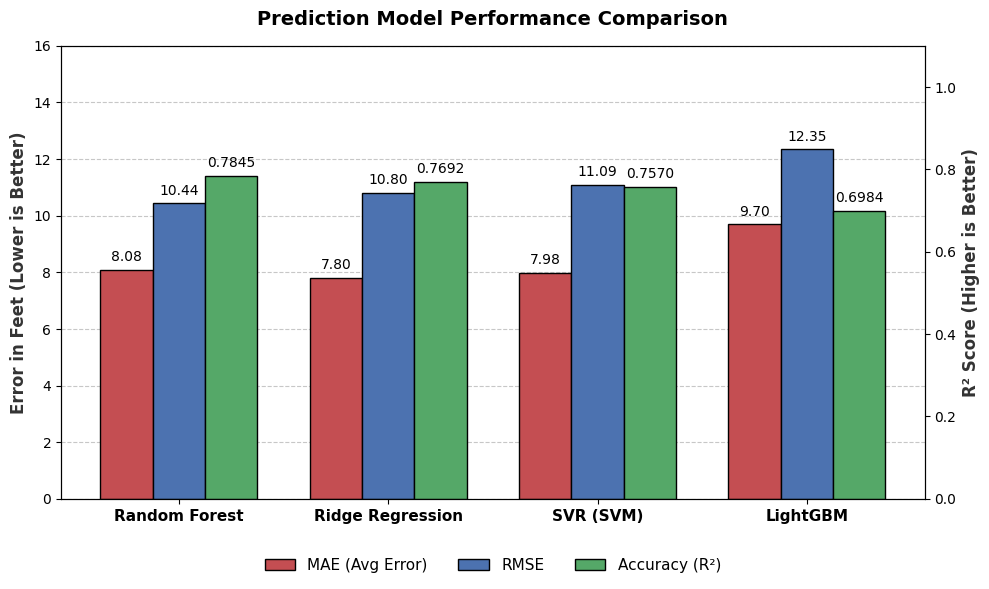

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

def plot_final_metrics():
    # =========================================================================
    # EXACT DATA FROM YOUR TABLE
    # =========================================================================
    models = ['Random Forest', 'Ridge Regression', 'SVR (SVM)', 'LightGBM']

    # Metrics
    r2_scores = [0.7845, 0.7692, 0.7570, 0.6984]
    mae_errors = [8.08, 7.80, 7.98, 9.70]
    rmse_errors = [10.44, 10.80, 11.09, 12.35]

    # Bar positioning
    x = np.arange(len(models))
    width = 0.25

    # =========================================================================
    # PLOTTING LOGIC
    # =========================================================================
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # --- Axis 1: Errors (MAE & RMSE in feet) on the LEFT ---
    bar_mae = ax1.bar(x - width, mae_errors, width, label='MAE (Avg Error)', color='#c44e52', edgecolor='black')
    bar_rmse = ax1.bar(x, rmse_errors, width, label='RMSE', color='#4c72b0', edgecolor='black')

    ax1.set_ylabel('Error in Feet (Lower is Better)', fontsize=12, fontweight='bold', color='#333333')
    ax1.set_ylim(0, 16) # Gives breathing room for the text labels above the bars
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    ax1.set_axisbelow(True)

    # --- Axis 2: Accuracy (R2) on the RIGHT ---
    ax2 = ax1.twinx()
    bar_r2 = ax2.bar(x + width, r2_scores, width, label='Accuracy (R²)', color='#55a868', edgecolor='black')

    ax2.set_ylabel('R² Score (Higher is Better)', fontsize=12, fontweight='bold', color='#333333')
    ax2.set_ylim(0, 1.1)

    # --- Formatting & Text Labels ---
    ax1.set_title('Prediction Model Performance Comparison', fontsize=14, fontweight='bold', pad=15)
    ax1.set_xticks(x)
    ax1.set_xticklabels(models, fontsize=11, fontweight='bold')

    # Add the exact numbers floating above each bar
    for bar in bar_mae:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)
    for bar in bar_rmse:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)
    for bar in bar_r2:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015, f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)

    # --- Combined Legend ---
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False, fontsize=11)

    # Output and Download
    plt.tight_layout()
    output_filename = 'prediction_metrics_comparison.png'
    plt.savefig(output_filename, dpi=400, bbox_inches='tight')
    plt.show()

    try:
        files.download(output_filename)
    except:
        pass

if __name__ == '__main__':
    plot_final_metrics()